- Problem Definition
- Data Collection
- Data Exploration and Analysis (EDA)
- Data Preprocessing
- Feature Selection
- Model Selection
- Model Training
- Model Evaluation
- Hyperparameter Tuning
- Model Deployment

#### Step 1 : Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings('ignore')

#### Step 2 : Read the dataset

In [3]:
df = pd.read_csv('Data/height-weight.csv')
df.shape

(100, 2)

In [4]:
df

,Weight,Height
0,27,55
1,28,48
2,29,53
3,30,58
4,31,65
...,...,...
95,46,72
96,48,75
97,50,79
98,52,83


#### Step 3 : Plot the Graph between Independent variable vs Dependent variable

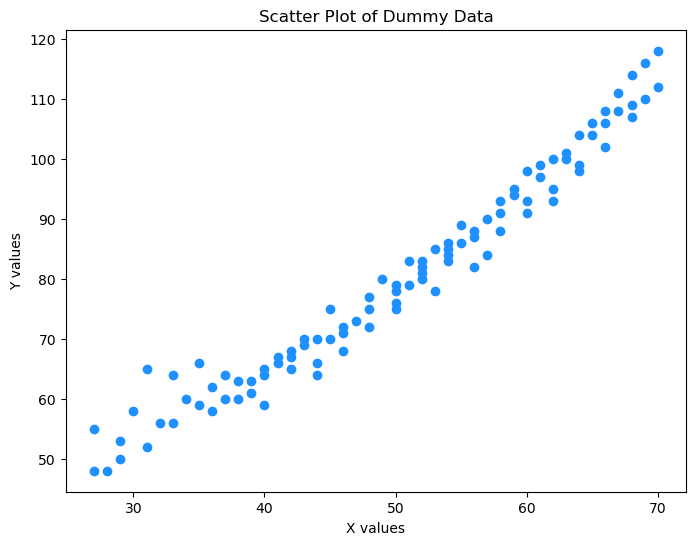

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(x=df['Weight'],y=df['Height'], color='dodgerblue')
plt.title("Scatter Plot of Dummy Data")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.show()

### Simple Linear Regression

#### Step 4 :- Divide Our Dataset into independent and dependent features

In [6]:
## Independent and dependent features
X=df[['Weight']] ### independent features should be data frame or 2 dimesnional array
y=df['Height'] ## this variiable can be in series or 1d array

#### Step :-5 Split Data into Trian and Test data

1. **`X` and `y`**:
   - `X` is the independent feature(s) (in this case, `Weight`).
   - `y` is the dependent feature or target variable (`Height`).
   
2. **`test_size=0.20`**:
   - Specifies the proportion of the dataset to include in the test split. Here, `0.20` means 20% of the data will go to the test set, and 80% to the training set.
   
3. **`random_state=42`**:
   - Setting `random_state` ensures the same random split each time you run the code. This makes results reproducible, allowing you (and others) to get the same training and testing sets.

The output variables are:

- **`X_train`** and **`y_train`**: Training data and labels (80% of the original data).
- **`X_test`** and **`y_test`**: Testing data and labels (20% of the original data).

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
# Train test split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [10]:
X.shape

(100, 1)

In [11]:
X_train

,Weight
55,62
88,69
26,53
42,69
69,50
...,...
60,43
71,52
14,41
92,40


In [12]:
X_train.shape , X_test.shape

((80, 1), (20, 1))

In [13]:
y_train.shape , y_test.shape

((80,), (20,))

#### Stpe :- 6 standardize the dataset Train Independent data
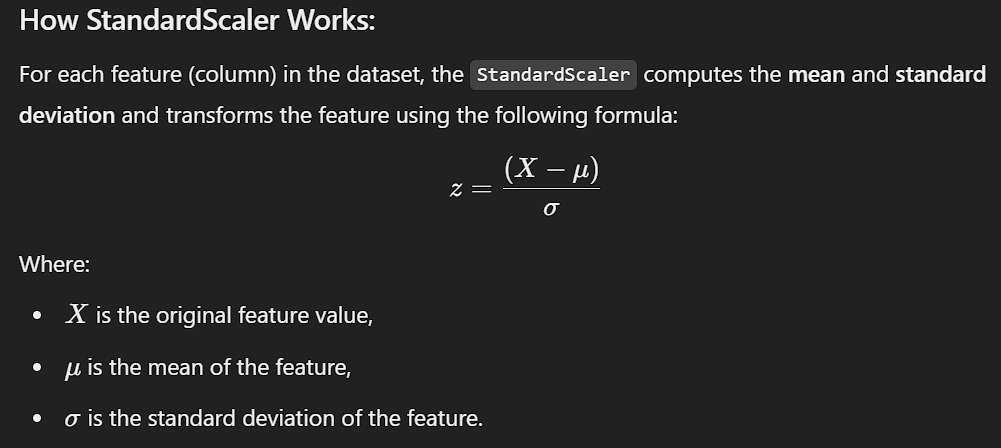
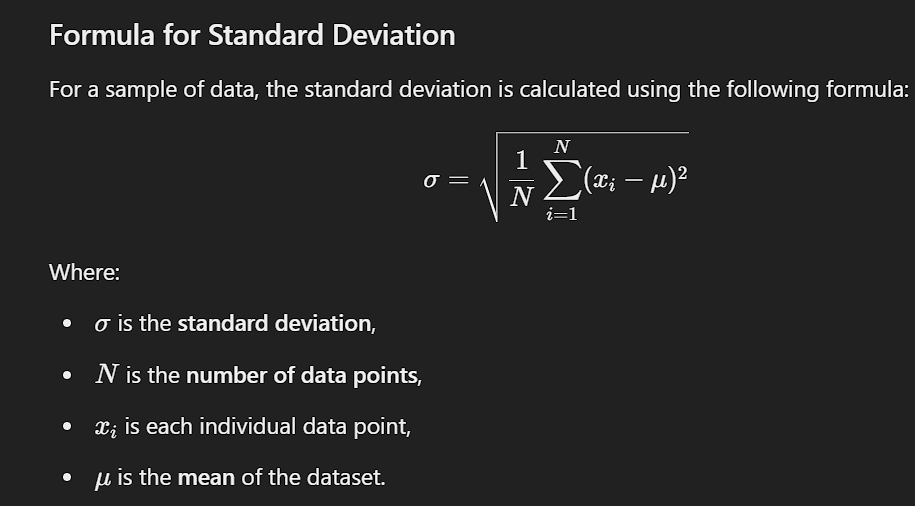

In [14]:
## Standardization
from sklearn.preprocessing import StandardScaler

In [15]:
Scaler = StandardScaler()

- **StandardScaler**: Standardizes the independent variable (`Weight`) by centering around the mean and scaling to unit variance.
  - `fit_transform(X_train)`: Computes mean and standard deviation from `X_train` and scales the data.
  - `transform(X_test)`: Scales `X_test` using the same parameters to ensure consistency, avoiding data leakage.

In [16]:
X_train_Scaled = Scaler.fit_transform(X_train)
X_test_Scaled = Scaler.transform(X_test)

In [17]:
X_test_Scaled

array([[ 1.1308805 ],
       [ 0.63560437],
       [ 0.05778222],
       [-0.68513198],
       [-0.85022403],
       [ 1.29597254],
       [-0.10730983],
       [ 0.88324243],
       [-1.09786209],
       [-1.92332231],
       [-0.43749392],
       [ 0.55305835],
       [ 0.30542028],
       [ 0.80069641],
       [-1.18040811],
       [-1.59313822],
       [ 0.55305835],
       [ 0.63560437],
       [-0.93277005],
       [ 0.63560437]])

### Step :- 7 Building the Model

In [18]:
## Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [19]:
regressor = LinearRegression()

In [20]:
regressor.fit(X_train_Scaled,y_train)

LinearRegression()

In [21]:
# y = mx + b
# m = slop
# b = intercept
print(f"The slop or cofficient of weight is :- {regressor.coef_}")
print(f"Intercept :- {regressor.intercept_}")

The slop or cofficient of weight is :- [18.12370139]
Intercept :- 80.5125


In [22]:
X_train_Scaled.shape , y_train.shape

((80, 1), (80,))

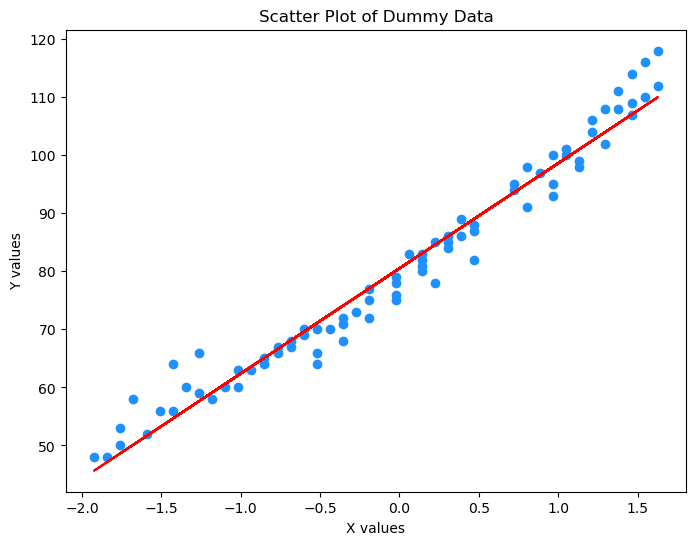

In [23]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train_Scaled,y_train, color='dodgerblue')

# Regression Line
plt.plot(X_train_Scaled,regressor.predict(X_train_Scaled),'r')

plt.title("Scatter Plot of Dummy Data")
plt.xlabel("X values")
plt.ylabel("Y values")
plt.show()

### Prediction of train data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =80.5125 + 18.12370139(X_train)

In [24]:
y_pred_train = regressor.predict(X_train_Scaled)
y_pred_train

array([ 98.01616159, 108.48843776,  84.55180652, 108.48843776,
        80.06368816,  68.09537255, 105.49635885,  77.07160926,
        59.11913583,  84.55180652,  62.11121474,  74.07953036,
       104.0003194 ,  87.54388543,  68.09537255,  53.13497803,
        51.63893857,  54.63101748,  98.01616159,  69.591412  ,
        80.06368816,  96.52012214,  56.12705693,  74.07953036,
        86.04784597,  74.07953036,  98.01616159,  83.05576707,
        63.60725419,  65.10329364,  81.55972762,  50.14289912,
        71.08745145, 102.50427995,  57.62309638,  93.52804323,
        54.63101748,  57.62309638,  99.51220104, 109.98447721,
       101.00824049,  86.04784597,  95.02408269, 109.98447721,
        83.05576707,  48.64685967,  71.08745145,  45.65478076,
        66.59933309,  80.06368816,  95.02408269, 106.9923983 ,
       106.9923983 ,  77.07160926,  83.05576707, 104.0003194 ,
        89.03992488,  93.52804323,  71.08745145,  72.5834909 ,
        60.61517529, 102.50427995, 101.00824049,  89.03

In [25]:
# Create the DataFrame
results_df = pd.DataFrame({
    'Actual': y_train,        
    'Predicted': y_pred_train.flatten()
})
results_df

,Actual,Predicted
55,93,98.016162
88,116,108.488438
26,78,84.551807
42,110,108.488438
69,78,80.063688
...,...,...
60,69,69.591412
71,82,83.055767
14,66,66.599333
92,65,65.103294


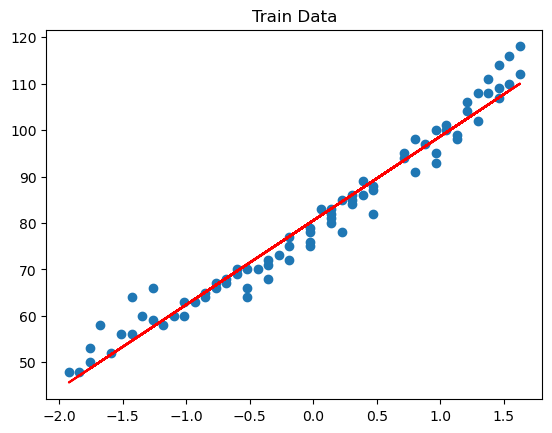

In [29]:
plt.scatter(X_train_Scaled,y_train)
plt.plot(X_train_Scaled,regressor.predict(X_train_Scaled),'r')
plt.title('Train Data')
plt.show()

### Prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =157.5 + 17.03(X_test)

In [34]:
y_pred_test = regressor.predict(X_test_Scaled)

In [35]:
y_pred_test , y_test

(array([101.00824049,  92.03200378,  81.55972762,  68.09537255,
         65.10329364, 104.0003194 ,  78.56764871,  96.52012214,
         60.61517529,  45.65478076,  72.5834909 ,  90.53596433,
         86.04784597,  95.02408269,  59.11913583,  51.63893857,
         90.53596433,  92.03200378,  63.60725419,  92.03200378]),
 83    104
 53     88
 70     79
 45     65
 44     59
 39    106
 22     80
 80     99
 10     64
 0      55
 18     75
 30     84
 73     83
 33     93
 90     62
 4      65
 76     90
 77     93
 12     61
 31     91
 Name: Height, dtype: int64)

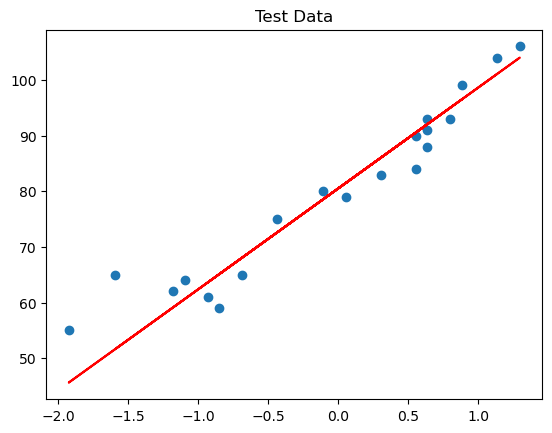

In [36]:
plt.scatter(X_test_Scaled,y_test)
plt.plot(X_test_Scaled,regressor.predict(X_test_Scaled),'r')
plt.title('Test Data')
plt.show()

## Performace Metrics

- MSE,MAE , RMSE
- R Square and adjusted R Square

In [37]:
from sklearn.metrics import mean_squared_error , mean_absolute_error

In [38]:
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)

In [39]:
print(f"Mean Square Error   :- {mse}")
print(f"Mean Absolute Error :- {mae}")
print(f"RMSE                :- {rmse}")

Mean Square Error   :- 22.371538020356866
Mean Absolute Error :- 3.6416828495502855
RMSE                :- 4.7298560253306725


##### To find how our model working

## R square 
Formula

In [40]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred_test)

In [41]:
print("%.2f%%" %(100*score))

90.57%


#### Adjusted R2

In [42]:
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.9004283975218839

### How to Predict New Values

In [43]:
scaled_weight = Scaler.transform([[45]])
scaled_weight[0]

array([-0.43749392])

In [44]:
x = -0.43749392

m = 18.12370139
b = 80.5125

y = m * x + b
print(y)

72.58349083397945


In [51]:
# New data point weight is 50
scaled_weight = Scaler.transform([[50]])
scaled_weight

array([[-0.02476381]])

In [52]:
Model_Prediction = regressor.predict([scaled_weight[0]])
Model_Prediction

array([80.06368816])

In [53]:
print(f"The height prediction for weight 50 kg is :- {Model_Prediction[0]}")

The height prediction for weight 50 kg is :- 80.06368816434997


### Assumptions

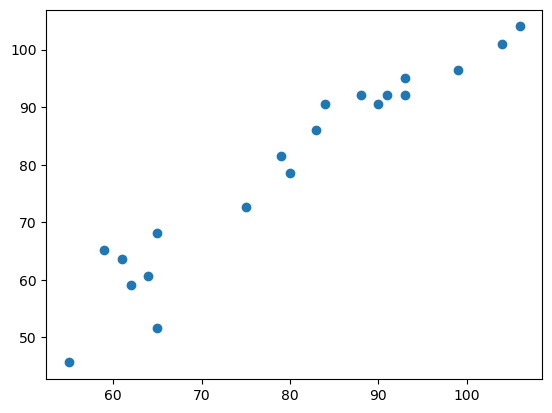

In [54]:

## plot a scatter plot for the prediction
# We say that our model is functioning well if our plot is sort of linear.
plt.scatter(y_test,y_pred_test)
plt.show()

In [55]:
# Residuals

residule = y_test - y_pred_test
residule

83     2.991760
53    -4.032004
70    -2.559728
45    -3.095373
44    -6.103294
39     1.999681
22     1.432351
80     2.479878
10     3.384825
0      9.345219
18     2.416509
30    -6.535964
73    -3.047846
33    -2.024083
90     2.880864
4     13.361061
76    -0.535964
77     0.967996
12    -2.607254
31    -1.032004
Name: Height, dtype: float64

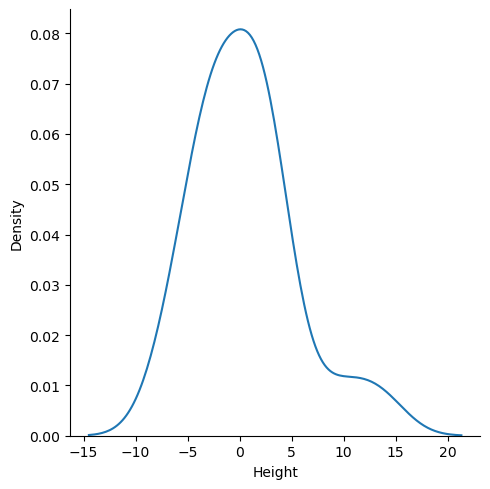

In [56]:
# Plot this Residuals
# Its should look like "Normal Distributions"

import seaborn as sns
sns.displot(residule,kind="kde")
plt.show()

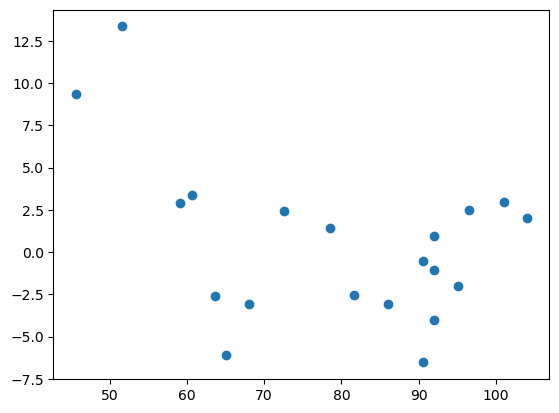

In [57]:
# Scatter plot with respect to prediction and residuals
# its should look like "Uniform distribution"
plt.scatter(y_pred_test,residule)
plt.show()